<a href="https://colab.research.google.com/github/DeepsaranNS/AI-Engineering-Roadmap/blob/main/Phase_0_Titanic_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Initial Scripting - Basic List, Loops and Condition
my_list = [89, 56, 87, 45, 24]

for num in my_list:
  if num % 2 == 0:
    print(num)

56
24


In [ ]:
import pandas as pd

# Creating a dictionary of data
fleet_data = {
    "Asset": ["INS Vikrant", "P-8I Poseidon", "INS Vikramaditya", "INS Khukri"],
    "Commission_Year": [2022, 2013, 2013, 1989]
}

# Converting it into a pandas DataFrame
df = pd.DataFrame(fleet_data)

print(df)

              Asset  Commission_Year
0       INS Vikrant             2022
1     P-8I Poseidon             2013
2  INS Vikramaditya             2013
3        INS Khukri             1989


In [ ]:
# Vectorized filtering: No loops needed!
modern_fleet = df[df["Commission_Year"] > 2000]

print(modern_fleet)

              Asset  Commission_Year
0       INS Vikrant             2022
1     P-8I Poseidon             2013
2  INS Vikramaditya             2013


In [ ]:
modern_fleet.head()

,Asset,Commission_Year
0,INS Vikrant,2022
1,P-8I Poseidon,2013
2,INS Vikramaditya,2013


In [ ]:
import pandas as pd

# 1. Provide the URL to the raw CSV file
csv_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# 2. Use pandas to read the URL and turn it into a DataFrame
real_df = pd.read_csv(csv_url)

# 3. Look at the first 5 rows of the data
real_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Check for missing values in every column
real_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
import pandas as pd
csv_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
real_df = pd.read_csv(csv_url)

In [ ]:
real_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Create a new, clean version of the DataFrame by dropping the 'Cabin' column
clean_df = real_df.drop(columns=['Cabin'])

# Calculate the median age of the passengers
median_age = clean_df['Age'].median()

# Fill the missing ages in the 'Age' column with that median number
clean_df['Age'] = clean_df['Age'].fillna(median_age)

# Run our check from yesterday to verify the mess is cleaned up
print(clean_df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


In [ ]:
# 1. Drop the 2 rows where 'Embarked' is missing to make the data 100% clean
clean_df = clean_df.dropna(subset=['Embarked'])

In [ ]:
print(clean_df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
survival_by_class = clean_df.groupby('Pclass')['Survived'].mean()
print(survival_by_class)

Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64


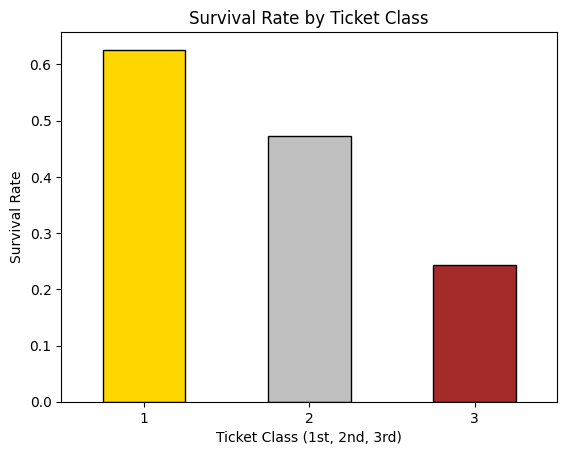

In [ ]:
import matplotlib.pyplot as plt

# --- PLOT 1: Bar Chart of Survival by Class ---
# We use the 'survival_by_class' variable you just created
survival_by_class.plot(kind='bar', color=['gold', 'silver', 'brown'], edgecolor='black')

plt.title('Survival Rate by Ticket Class')
plt.ylabel('Survival Rate')
plt.xlabel('Ticket Class (1st, 2nd, 3rd)')
plt.xticks(rotation=0) # Keeps the labels flat
plt.show() # This command tells Python to render the first chart

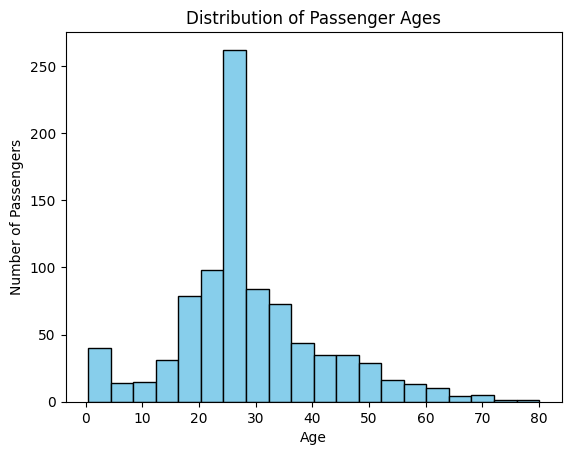

In [ ]:
# --- PLOT 2: Histogram of Passenger Ages ---
plt.hist(clean_df['Age'], bins=20, color='skyblue', edgecolor='black')

plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show() # This renders the second chart